# From ECG to HR and simple HRV (Principles: vagal tone, RSA)

## TODOs

1. Compute RMSSD and HF power during baseline vs stress masks. 
2. Describe which increases/decreases and why (vagal withdrawal during stress → lower RMSSD/HF).

## My notes

+ RMSSD (Root Mean Square of Successive Differences)
    - Calculate using the R-peaks, where these R-peaks are the heartbeats.
    - R-peaks come from ECG, where ECG has P-wave, QRS-complex, and T-wave.
    - Time domain.
    - Steps:
        1. From the ECG, detect the components: P-wave, QRS-complex, and T-wave. 
        2. Delineate ECG for R-peaks, where these R-peaks are the heartbeats
        3. Calculate RMSSD by passing in R-peaks to get HRV
            - 3.1 1 R-peak = 1 Heartbeat
            - 3.2 Consecutive R-peaks are RR-interval = consecutive HBs
                - 3.2.1  From RR-interval, calculate LF/HF
    - We want this value to be
        1. high bc it leads to better recovery + more ANS stimulaton?
            - high means more time between heartbeats
        2. varied bc it leads to better recovery
+ HF (High Frequency) power
    1. Frequency domain.
    2. Favors parasympathetic activity, which is rest and recovery/digest.
    3. We want this value to be high bc...

## Code

In [1]:
import os
import pickle

import numpy as np
import pandas as pd

import neurokit2 as nk

import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.signal import find_peaks, welch
from adtk.data import validate_series
from adtk.detector import ThresholdAD

notebook_dir = os.getcwd()

## Load Data

In [2]:
data_path = os.path.join(notebook_dir, "../../../roeh-health/data/WESAD/all_subjects/chest.csv")
df = pd.read_csv(data_path)
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130950,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
60807595,0.9006,-0.0400,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
60807596,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.859740,0.233459,S17,0
60807597,0.9028,-0.0424,-0.1864,0.167130,-0.016068,7.262802,33.864290,0.318909,S17,0
60807598,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


In [3]:
def get_per_subject(df):
    per_subject = {}
    entries = df['subject'].unique()
    for entry in entries:
        filt_subject = (df['subject'] == entry)
        subject_df = df[filt_subject]
        subject_df.reset_index(inplace=True)
        per_subject[entry] = subject_df
    return per_subject

In [4]:
per_subject_dfs = get_per_subject(df)
per_subject_dfs

{'S2':            index   ACC_x   ACC_y   ACC_z       ECG       EMG       EDA  \
 0              0  0.9554 -0.2220 -0.5580  0.021423 -0.004440  5.250549   
 1              1  0.9258 -0.2216 -0.5538  0.020325  0.004349  5.267334   
 2              2  0.9082 -0.2196 -0.5392  0.016525  0.005173  5.243301   
 3              3  0.8974 -0.2102 -0.5122  0.016708  0.007187  5.249405   
 4              4  0.8882 -0.2036 -0.4824  0.011673 -0.015152  5.286407   
 ...          ...     ...     ...     ...       ...       ...       ...   
 4255295  4255295  0.8750 -0.1234 -0.2974 -0.013138  0.020370  0.400162   
 4255296  4255296  0.8750 -0.1262 -0.2988 -0.010345  0.019592  0.355911   
 4255297  4255297  0.8718 -0.1238 -0.3042 -0.005447 -0.017166  0.360489   
 4255298  4255298  0.8730 -0.1234 -0.3026  0.000137 -0.028976  0.365829   
 4255299  4255299  0.8702 -0.1220 -0.3022  0.004074 -0.023575  0.365448   
 
               Temp      Resp subject  label  
 0        30.120758 -1.148987      S2      0 

In [5]:
s_df = per_subject_dfs['S7']
s_df

,index,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,22626800,1.0696,-0.0140,1.4612,-0.019226,-0.048843,12.506866,33.993530,1.832581,S7,0
1,22626801,1.0654,-0.0102,1.4222,-0.016937,-0.007004,12.468719,33.932680,1.835632,S7,0
2,22626802,1.0654,0.0042,1.3202,-0.016159,0.071777,12.506866,33.970703,1.856995,S7,0
3,22626803,1.0666,0.0202,1.1464,-0.012405,0.088486,12.506485,34.008760,1.829529,S7,0
4,22626804,1.0602,0.0310,0.9192,-0.020325,0.090271,12.504959,33.887085,1.817322,S7,0
...,...,...,...,...,...,...,...,...,...,...,...
3666595,26293395,0.8586,-0.0958,-0.0390,0.156418,-0.036942,13.085556,34.917084,0.813293,S7,0
3666596,26293396,0.8526,-0.1026,-0.0430,0.115723,0.098831,13.089371,34.935608,0.816345,S7,0
3666597,26293397,0.8466,-0.1082,-0.0574,0.086380,0.199768,13.090134,34.943300,0.804138,S7,0
3666598,26293398,0.8422,-0.1138,-0.0814,0.139938,0.227646,13.081360,34.940247,0.834656,S7,0


In [6]:
subset_data_N = 126000
subset_series = s_df.loc[:subset_data_N, "ECG"]
subset_series

0        -0.019226
1        -0.016937
2        -0.016159
3        -0.012405
4        -0.020325
            ...   
125996   -0.041153
125997    0.050491
125998    0.184387
125999    0.351151
126000    0.559250
Name: ECG, Length: 126001, dtype: float64

In [15]:
splits = np.array_split(subset_series, 3)
len(splits[0])

42001

In [8]:
def rr_from_ecg(ecg, fs, min_rr=0.3, max_rr=2.0):
    """Very simple R-peak detection + RR intervals (seconds)."""
    x = (ecg - np.median(ecg)) / (np.std(ecg) + 1e-9)
    peak_idxs, _ = find_peaks(x, distance=int(min_rr*fs), prominence=np.std(x)*0.5)
    rr = np.diff(peak_idxs) / fs
    rr = rr[(rr > min_rr) & (rr < max_rr)]
    return peak_idxs, rr

In [9]:
def hrv_time(rr):
    """Basic time-domain HRV: SDNN, RMSSD, pNN50."""
    rr_ms = rr * 1000.0
    sdnn = np.std(rr_ms, ddof=1)
    diff = np.diff(rr_ms)
    rmssd = np.sqrt(np.mean(diff**2))
    pnn50 = np.mean(np.abs(diff) > 50.0) * 100.0
    return {'SDNN_ms': sdnn, 'RMSSD_ms': rmssd, 'pNN50_%': pnn50}


In [10]:
def hrv_freq(rr, fs_interp=4.0):
    """Welch PSD on interpolated tachogram → LF/HF power."""
    t = np.cumsum(rr)
    t = t - t[0]
    f = interp1d(t, rr, kind='linear', fill_value="extrapolate")
    t_even = np.arange(0, t[-1], 1.0/fs_interp)
    rr_even = f(t_even)
    rr_even = (rr_even - np.mean(rr_even))
    fxx, pxx = welch(rr_even, fs=fs_interp, nperseg=min(256, len(rr_even)))
    
    def band_power(fb):
        idx = np.logical_and(fxx >= fb[0], fxx < fb[1])
        return np.trapz(pxx[idx], fxx[idx])
    
    lf = band_power((0.04, 0.15))
    hf = band_power((0.15, 0.40))
    return {'LF': lf, 'HF': hf, 'LF_HF': (lf / hf) if hf > 0 else np.nan}

In [ ]:
def detect_anomaly(peak_times, peak_amplitudes):
    """
    Detect anomalies in peak amplitudes using ADTK ThresholdAD.
    
    Parameters
    ----------
    peak_times : array_like
        Times of detected peaks in seconds.
    peak_amplitudes : array_like
        Amplitudes of detected peaks.
    
    Returns
    -------
    anomolies : pd.Series
        Boolean series indicating anomalies.
    anomaly_mask : np.ndarray
        Boolean array mask for anomalies.
    anomaly_times : np.ndarray
        Times of anomalous peaks.
    anomaly_amplitudes : np.ndarray
        Amplitudes of anomalous peaks.
    low_threshold : float
        Lower threshold value.
    high_threshold : float
        Upper threshold value.
    """
    # Convert to pandas Series with DateTimeIndex for ADTK
    peak_series = pd.Series(
        peak_amplitudes,
        index=pd.to_datetime(peak_times, unit='s', origin='unix')
    )
    
    # Statistical approach
    mean_amp = np.mean(peak_amplitudes)
    std_amp = np.std(peak_amplitudes)
    low_threshold = mean_amp - 3*std_amp
    high_threshold = mean_amp + 3*std_amp
    
    anomoly_detector = ThresholdAD(low=low_threshold, high=high_threshold)
    anomolies = anomoly_detector.detect(peak_series)
    
    
    # Get anomaly indices and values
    anomaly_mask = anomolies.values
    print()
    print(peak_times)
    print(anomaly_mask)
    print()
    anomaly_times = peak_times[anomaly_mask]
    anomaly_amplitudes = peak_amplitudes[anomaly_mask]
    
    return anomolies, anomaly_mask, anomaly_times, anomaly_amplitudes, low_threshold, high_threshold

In [ ]:
def plot_ecg_segment(ecg, peak_idxs, fs_ecg, segment_idx, segment_duration=10):
    """
    Plot a single ECG segment with detected R-peaks and anomalies.
    
    Parameters
    ----------
    ecg : array_like
        The ECG signal data.
    peak_idxs : array_like
        Indices of detected R-peaks.
    fs_ecg : float
        Sampling frequency of the ECG signal.
    segment_idx : int
        Index of the segment to plot (0-based).
    segment_duration : int, optional
        Duration of each segment in seconds (default is 10).
    
    Returns
    -------
    None
    """
    t_ecg = np.arange(len(ecg)) / fs_ecg

    # Extract peak information
    peak_times = t_ecg[peak_idxs]
    print()
    print()
    print(peak_times)
    peak_amplitudes = ecg[peak_idxs]
    print(peak_amplitudes)
    print()
    


    
    # Detect anomalies
    anomolies, anomaly_mask, anomaly_times, anomaly_amplitudes, low_threshold, high_threshold = detect_anomaly(
        peak_times=peak_times, 
        peak_amplitudes=peak_amplitudes
    )
    
    # Separate normal and anomalous peaks
    normal_mask = ~anomaly_mask
    normal_times = peak_times[normal_mask]
    normal_amplitudes = peak_amplitudes[normal_mask]
    
    # Print peak information
    print(f"\n=== Segment {segment_idx + 1} Peak Information ===")
    print(f"\tPeak Amplitudes: {peak_amplitudes}")
    print(f"\tNumber of peaks in segment: {len(peak_idxs)}")
    print(f"\tMean amplitude: {np.mean(peak_amplitudes):.4f}")
    print(f"\tStd amplitude: {np.std(peak_amplitudes):.4f}")
    print(f"\tThresholds: [{low_threshold:.4f}, {high_threshold:.4f}]")
    print(f"\tMin amplitude: {np.min(peak_amplitudes):.4f}")
    print(f"\tMax amplitude: {np.max(peak_amplitudes):.4f}")
    print(f"\tNumber of anomalies: {np.sum(anomaly_mask)}")
    if np.sum(anomaly_mask) > 0:
        print(f"\tAnomaly amplitudes: {anomaly_amplitudes}")
        print(f"\tAnomaly times (s): {anomaly_times}")
    
    # Plot
    plt.figure(figsize=(12, 3))
    plt.plot(t_ecg, ecg, lw=0.7, label='ECG signal', color='blue')
    
    # Plot normal peaks in green
    if len(normal_times) > 0:
        plt.plot(normal_times, normal_amplitudes, 'go', ms=5, label=f'Normal R-peaks ({len(normal_times)})')
    
    # Plot anomalies in red with larger markers
    if len(anomaly_times) > 0:
        plt.plot(anomaly_times, anomaly_amplitudes, 'ro', ms=8, label=f'Anomalous peaks ({len(anomaly_times)})', 
                markeredgewidth=1.5, markeredgecolor='darkred')
    
    # Add threshold lines
    plt.axhline(y=low_threshold, color='orange', linestyle='--', alpha=0.7, linewidth=1.5, 
                label=f'Low threshold ({low_threshold:.2f})')
    plt.axhline(y=high_threshold, color='orange', linestyle='--', alpha=0.7, linewidth=1.5, 
                label=f'High threshold ({high_threshold:.2f})')
    
    # Annotate first few peaks with their amplitudes
    for i, (t, amp) in enumerate(zip(peak_times[:5], peak_amplitudes[:5])):
        plt.annotate(f'{amp:.3f}', xy=(t, amp), xytext=(0, 10), 
                    textcoords='offset points', ha='center', fontsize=8)
    
    plt.title(f"ECG segment {segment_idx + 1} (seconds {segment_idx*segment_duration} to {(segment_idx+1)*segment_duration})")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print()
    print()

In [37]:
fs_ecg = 700.0  # Use correct sampling rate from WESAD

collect_hrv_time_metrics = []
collect_hrv_freq_metrics = []
for split in splits:
    peaks, rr = rr_from_ecg(split, fs_ecg)
    # print(f"Detected {len(peaks)} R-peaks from {source}. RR count={len(rr)}\n")
    print(f"Time-domain HRV: {hrv_time(rr)}\n")
    print(f"Freq-domain HRV: {hrv_freq(rr)}")
    collect_hrv_time_metrics.append(hrv_time(rr))
    collect_hrv_freq_metrics.append(hrv_freq(rr))
    
    # Plot each segment separately
    # plot_ecg_segment(split, peaks, fs_ecg, segment_idx=0, segment_duration=60)

collect_hrv_time_metrics

Time-domain HRV: {'SDNN_ms': np.float64(90.33158947933251), 'RMSSD_ms': np.float64(61.0129760282503), 'pNN50_%': np.float64(27.631578947368425)}

Freq-domain HRV: {'LF': np.float64(0.0035438403793971907), 'HF': np.float64(0.000923073574490629), 'LF_HF': np.float64(3.839174338137407)}
Time-domain HRV: {'SDNN_ms': np.float64(132.78351027268675), 'RMSSD_ms': np.float64(122.57287949286341), 'pNN50_%': np.float64(38.57142857142858)}

Freq-domain HRV: {'LF': np.float64(0.0029333184485515144), 'HF': np.float64(0.005153521906226324), 'LF_HF': np.float64(0.5691871504431892)}
Time-domain HRV: {'SDNN_ms': np.float64(121.63791131002966), 'RMSSD_ms': np.float64(91.86071526271357), 'pNN50_%': np.float64(49.275362318840585)}

Freq-domain HRV: {'LF': np.float64(0.007999340915388141), 'HF': np.float64(0.0025892953316675425), 'LF_HF': np.float64(3.0893891544756515)}


/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_59534/885799439.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(pxx[idx], fxx[idx])


[{'SDNN_ms': np.float64(90.33158947933251),
  'RMSSD_ms': np.float64(61.0129760282503),
  'pNN50_%': np.float64(27.631578947368425)},
 {'SDNN_ms': np.float64(132.78351027268675),
  'RMSSD_ms': np.float64(122.57287949286341),
  'pNN50_%': np.float64(38.57142857142858)},
 {'SDNN_ms': np.float64(121.63791131002966),
  'RMSSD_ms': np.float64(91.86071526271357),
  'pNN50_%': np.float64(49.275362318840585)}]

In [39]:
collect_hrv_time_metrics_df = pd.DataFrame(collect_hrv_time_metrics)
collect_hrv_time_metrics_df

,SDNN_ms,RMSSD_ms,pNN50_%
0,90.331589,61.012976,27.631579
1,132.783510,122.572879,38.571429
2,121.637911,91.860715,49.275362


<Axes: >

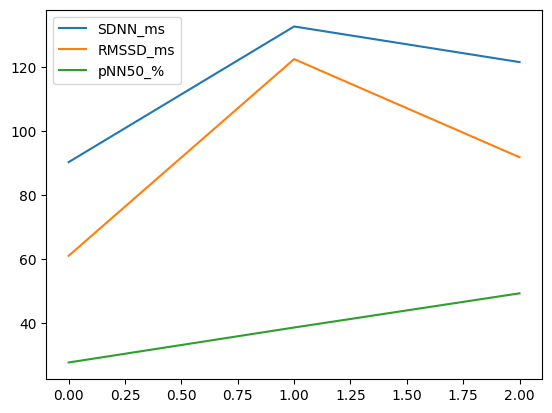

In [40]:
collect_hrv_time_metrics_df.plot.line()

> - There exists one anomaly, the first R-peak detected. Assumption is that this is "normal" or always happen?
> - Low threshold is value i from the standard deviation and High threshold is value j from the standard deviation
> - Standard deviation is the distance from the mean $\newline$
    - Low = close to mean, less variability/spread $\newline$
    - High = far from mean, more variability/spread

- Would we want a high standard deviation, which in turn leads to a lower valued low threshold and a higher valued high threshold? This would indicate more variability of the R-Peaks. 

In [35]:
collect_hrv_metrics

{'0       -0.019226\n1       -0.016937\n2       -0.016159\n3       -0.012405\n4       -0.020325\n           ...   \n41996   -0.057724\n41997   -0.055344\n41998   -0.050491\n41999   -0.045364\n42000   -0.040878\nName: ECG, Length: 42001, dtype: float64': {'time': {'SDNN_ms': np.float64(90.33158947933251),
   'RMSSD_ms': np.float64(61.0129760282503),
   'pNN50_%': np.float64(27.631578947368425)},
  'freq': {'LF': np.float64(0.0035438403793971907),
   'HF': np.float64(0.000923073574490629),
   'LF_HF': np.float64(3.839174338137407)}},
 '42001   -0.041794\n42002   -0.043808\n42003   -0.044724\n42004   -0.043396\n42005   -0.044083\n           ...   \n83996   -0.056946\n83997   -0.053238\n83998   -0.047653\n83999   -0.047562\n84000   -0.054016\nName: ECG, Length: 42000, dtype: float64': {'time': {'SDNN_ms': np.float64(132.78351027268675),
   'RMSSD_ms': np.float64(122.57287949286341),
   'pNN50_%': np.float64(38.57142857142858)},
  'freq': {'LF': np.float64(0.0029333184485515144),
   'HF': n

In [ ]:
if ecg is not None:
    peaks, rr = rr_from_ecg(ecg, fs_ecg)
    # print(f"Detected {len(peaks)} R-peaks from {source}. RR count={len(rr)}\n")
    print(f"Time-domain HRV: {hrv_time(rr)}\n")
    print(f"Freq-domain HRV: {hrv_freq(rr)}")
    
    # Plot each segment separately
    plot_ecg_segment(ecg, peaks, fs_ecg, segment_idx=1, segment_duration=60)
else:
    print("No ECG channel found.")

> There exists one R-peak anomaly bc it falls outside of the low threshold value. 

In [ ]:
if ecg is not None:
    peaks, rr = rr_from_ecg(ecg, fs_ecg)
    # print(f"Detected {len(peaks)} R-peaks from {source}. RR count={len(rr)}\n")
    print(f"Time-domain HRV: {hrv_time(rr)}\n")
    print(f"Freq-domain HRV: {hrv_freq(rr)}")
    
    # Plot each segment separately
    plot_ecg_segment(ecg, peaks, fs_ecg, segment_idx=2, segment_duration=60)
else:
    print("No ECG channel found.")

> There exist no anomalies because all values fall within the low and high thresholds. 

> - With the code above, I see that the image or the figure is showing roughly 10 seconds. Are we saying that the entirety of this subject's data is 10 seconds, or we sample only 10 seconds from this subject's data? If the letter of sample is only 10 seconds, then how can I sample another 10 seconds? I don't fully understand the code given to me. Base your comments direct on my statements and questions line by line.

## Follow-Up

> - Be sure to see TODOs

1. What do we gather from this subject?
2. Is there anything to flag?
3. 'RMSSD_ms': np.float64(698.4470516017469)
    - Why?
    - Good/Bad?
4. 'HF': np.float64(0.04114562090390898), why?
    - Why?
    - Good/Bad?
5. RMSSD_ms and HF considered jointly
    - If one is good and other bad? Vice versa
    - If both are good? Both are bad?

### 1. What do we gather from this subject?

> - R-peaks (aka heartbeats in green).


In [ ]:
# Could say something based on the avg of the window of 60 secs or take last

# Choose sampling rate and adjustable
# 